In [ ]:
# -----------------------------
# Skipgram Word2Vec with Negative Sampling (Google Colab Ready)
# -----------------------------

import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import random
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

# -----------------------------
# 1. Download and Load text8 dataset


# Corrected file path for Colab
data_path = "/content/drive/MyDrive/text8.zip"

with zipfile.ZipFile(data_path) as f:
    text = f.read("text8").decode("utf-8")

# Tokenize into words
tokens = text.split()
print("Total tokens:", len(tokens))

# -----------------------------
# 2. Build vocabulary
# -----------------------------
vocab_size = 50000  # limit vocab size
counter = Counter(tokens)
most_common = counter.most_common(vocab_size - 2)

vocab = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
vocab["<UNK>"] = 0
vocab["<PAD>"] = 1
id2word = {idx: word for word, idx in vocab.items()}

# Encode dataset
encoded = [vocab.get(t, 0) for t in tokens]
print("Vocab size:", len(vocab))
print("Sample encoded:", encoded[:20])

subset_size = 2_000_000
encoded = encoded[:subset_size]



Total tokens: 124301826
Vocab size: 50000
Sample encoded: [9560, 3425, 21, 9, 279, 3, 3453, 58, 84, 210, 176, 783, 502, 9840, 189, 2, 28375, 3, 2, 181]


In [ ]:
# -----------------------------
# 3. Dataset with Negative Sampling
# -----------------------------
class SkipGramDataset(Dataset):
    def __init__(self, encoded, vocab_size, window_size=2, negative_samples=5):
        self.pairs = []
        for idx, center in enumerate(encoded):
            window = random.randint(1, window_size)
            start = max(0, idx - window)
            end = min(len(encoded), idx + window + 1)
            for i in range(start, end):
                if i != idx:
                    self.pairs.append((center, encoded[i]))
        self.vocab_size = vocab_size
        self.negative_samples = negative_samples

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, pos = self.pairs[idx]
        negatives = []
        while len(negatives) < self.negative_samples:
            neg = random.randint(0, self.vocab_size - 1)
            if neg != center and neg != pos:
                negatives.append(neg)
        return (
            torch.tensor(center),
            torch.tensor(pos),
            torch.tensor(negatives)
        )

dataset = SkipGramDataset(encoded, len(vocab), window_size=2, negative_samples=5)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, drop_last=True)

print("Dataset ready, total pairs:", len(dataset))


class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, embed_dim=100):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_dim)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)

    def forward(self, center, pos, neg):
        center_emb = self.in_embed(center)
        pos_emb = self.out_embed(pos)
        neg_emb = self.out_embed(neg)

        pos_score = torch.mul(center_emb, pos_emb).sum(1)
        neg_score = torch.bmm(neg_emb, center_emb.unsqueeze(2)).squeeze()

        pos_loss = torch.log(torch.sigmoid(pos_score) + 1e-10)
        neg_loss = torch.log(torch.sigmoid(-neg_score) + 1e-10).sum(1)
        loss = -(pos_loss + neg_loss).mean()
        return loss, pos_score, neg_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SkipGramNS(len(vocab), embed_dim=100).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.003)

EPOCHS = 5 # start small for Colab
for epoch in range(EPOCHS):
    total_loss, total_correct, total_samples = 0, 0, 0

    for i, (center, pos, neg) in enumerate(dataloader):
        center, pos, neg = center.to(device), pos.to(device), neg.to(device)
        loss, pos_score, neg_score = model(center, pos, neg)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ---- Accuracy calculation ----
        pos_pred = (torch.sigmoid(pos_score) > 0.5).sum().item()
        neg_pred = (torch.sigmoid(neg_score) < 0.5).sum().item()

        total_correct += pos_pred + neg_pred
        total_samples += pos_score.size(0) + neg_score.numel()

        if (i+1) % 500 == 0:
            acc = 100 * total_correct / total_samples
            print(f"Step {i+1}, Avg Loss: {total_loss/(i+1):.4f}, Acc: {acc:.2f}%")

    epoch_acc = 100 * total_correct / total_samples
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}, Acc: {epoch_acc:.2f}%")

# Save embeddings
embeddings = model.in_embed.weight.data.cpu().numpy()

# -----------------------------
# 6. Word Similarity
# -----------------------------
def most_similar(word, topn=10):
    if word not in vocab:
        return []
    idx = vocab[word]
    vec = embeddings[idx]
    sims = np.dot(embeddings, vec) / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec) + 1e-10)
    best = np.argsort(-sims)[1:topn+1]
    return [(id2word[i], float(sims[i])) for i in best]

query_words = ["king", "queen", "computer", "science"]
for w in query_words:
    if w in vocab:
        print(f"\nTop similar words to '{w}':")
        for sim_word, score in most_similar(w, topn=5):
            print(f"  {sim_word} ({score:.4f})")


Dataset ready, total pairs: 5999686
Step 500, Avg Loss: 20.9216, Acc: 51.32%
Step 1000, Avg Loss: 18.9015, Acc: 52.17%
Step 1500, Avg Loss: 17.3300, Acc: 53.31%
Step 2000, Avg Loss: 16.1382, Acc: 54.74%
Step 2500, Avg Loss: 15.1461, Acc: 56.44%
Step 3000, Avg Loss: 14.2716, Acc: 58.43%
Step 3500, Avg Loss: 13.4710, Acc: 60.53%
Step 4000, Avg Loss: 12.7387, Acc: 62.52%
Step 4500, Avg Loss: 12.0805, Acc: 64.31%
Step 5000, Avg Loss: 11.4767, Acc: 65.93%
Step 5500, Avg Loss: 10.9327, Acc: 67.39%
Step 6000, Avg Loss: 10.4368, Acc: 68.72%
Step 6500, Avg Loss: 9.9841, Acc: 69.93%
Step 7000, Avg Loss: 9.5683, Acc: 71.04%
Step 7500, Avg Loss: 9.1889, Acc: 72.06%
Step 8000, Avg Loss: 8.8435, Acc: 72.99%
Step 8500, Avg Loss: 8.5225, Acc: 73.85%
Step 9000, Avg Loss: 8.2280, Acc: 74.65%
Step 9500, Avg Loss: 7.9547, Acc: 75.39%
Step 10000, Avg Loss: 7.7034, Acc: 76.07%
Step 10500, Avg Loss: 7.4704, Acc: 76.70%
Step 11000, Avg Loss: 7.2529, Acc: 77.29%
Step 11500, Avg Loss: 7.0519, Acc: 77.84%
Step 1

Running t-SNE on 500 words...


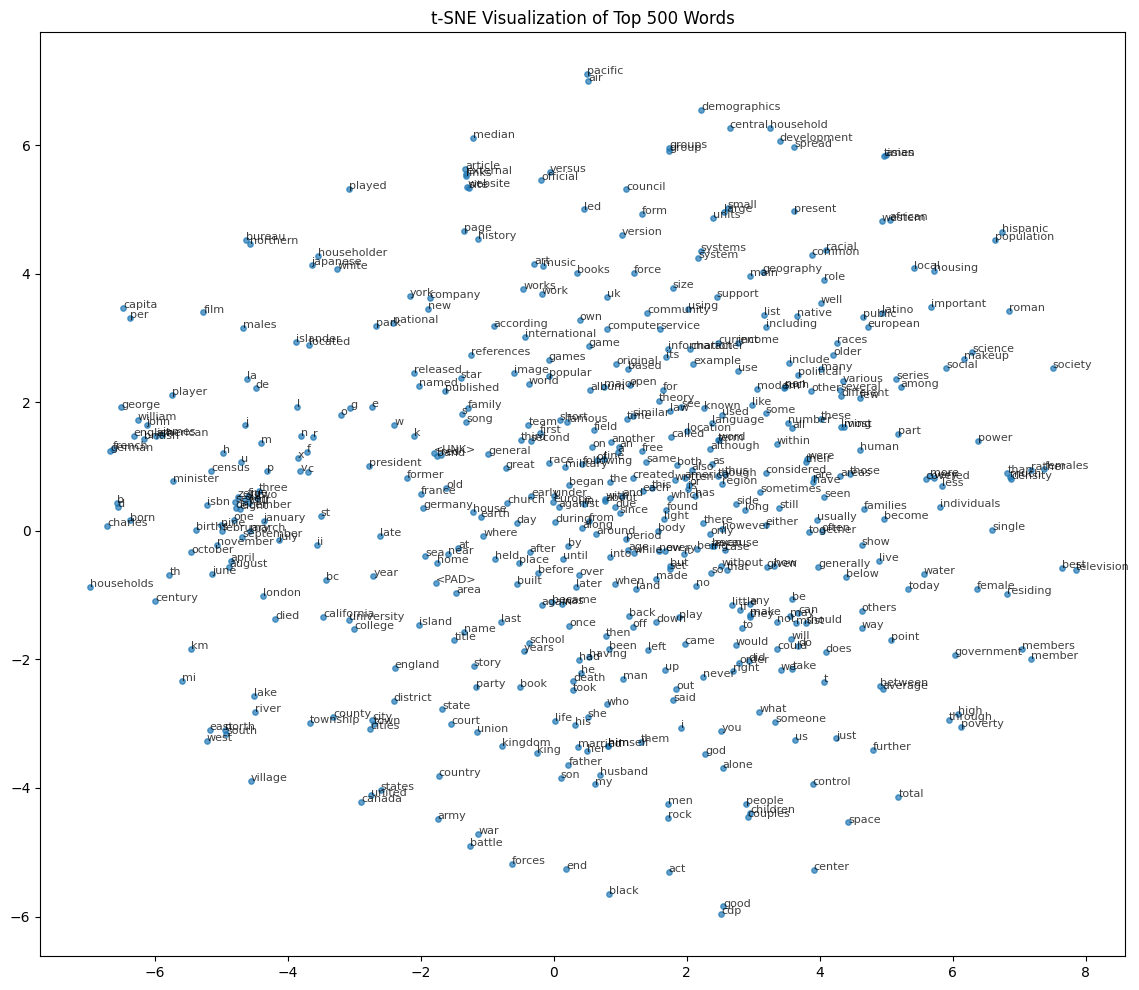

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne_embeddings(embeddings, id2word, top_n=500):
    """
    Visualize top_n word embeddings using t-SNE.
    """
    # Take the first top_n embeddings
    words = [id2word[i] for i in range(top_n)]
    vecs = embeddings[:top_n]

    print(f"Running t-SNE on {top_n} words...")
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=30 if top_n > 30 else top_n-1,
        init="pca",
        max_iter=3000
    )
    reduced = tsne.fit_transform(vecs)

    # Plot
    plt.figure(figsize=(14, 12))
    plt.scatter(reduced[:, 0], reduced[:, 1], s=15, alpha=0.7)

    for i, word in enumerate(words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=8, alpha=0.75)

    plt.title(f"t-SNE Visualization of Top {top_n} Words")
    plt.show()

# Example: visualize top 500 most frequent words
plot_tsne_embeddings(embeddings, id2word, top_n=500)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# -----------------------------
# 1. Get embeddings and words
# -----------------------------
# Select top-k frequent words for visualization
topk = 500  # or 1000 depending on memory
embeddings = model.in_embed.weight.detach().cpu().numpy()
words = [id2word[i] for i in range(vocab_size)]

# Filter top-k most frequent words
top_words = words[1:topk+1]  # skip 'UNK' at index 0
top_embeddings = embeddings[1:topk+1]

# -----------------------------
# 2. t-SNE Visualization
# -----------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(top_embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10)

for i, word in enumerate(top_words):
    if i % 20 == 0:  # label some words to avoid clutter
        plt.annotate(word, (tsne_results[i, 0], tsne_results[i, 1]), fontsize=8)

plt.title("Word Embeddings Visualized with t-SNE")
plt.show()

# -----------------------------
# 3. PCA Visualization
# -----------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(top_embeddings)

plt.figure(figsize=(12, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=10)

for i, word in enumerate(top_words):
    if i % 20 == 0:
        plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize=8)

plt.title("Word Embeddings Visualized with PCA")
plt.show()


NameError: name 'model' is not defined